# **Day 28: Classification Metrics**
*Module 5 - Classification*

The confusion matrix is the root of every classification metric. Today we build them all from it, learn which to use when, and cover the metrics specific to **map accuracy assessment** (user's/producer's accuracy, Kappa) that remote sensing journals expect.

> Accuracy alone can mislead. Precision asks "of the pixels I called flood, how many were flood?" and recall asks "of all flood pixels, how many did I find?". F1, ROC-AUC and the confusion matrix give a fuller picture.
>
> *Example:* A flood map with 95% precision but 40% recall looks clean but misses most of the flood. Emergency teams would be badly misled.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, fbeta_score, roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score, matthews_corrcoef, cohen_kappa_score,
                             balanced_accuracy_score, log_loss, brier_score_loss)
rng = np.random.default_rng(28)

## **1. The Confusion Matrix (Binary)**

| | Predicted positive | Predicted negative |
|---|---|---|
| **Actual positive** | TP (hit) | FN (miss, Type II) |
| **Actual negative** | FP (false alarm, Type I) | TN |

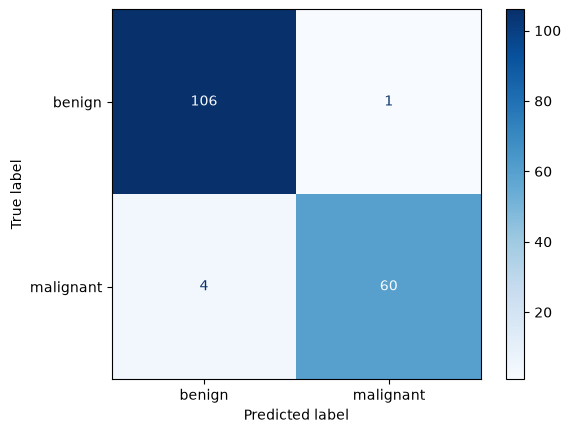

TP=60, FN=4, FP=1, TN=106


In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

X, y = load_breast_cancer(return_X_y=True); y = 1 - y           # 1 = malignant
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
clf = make_pipeline(StandardScaler(), LogisticRegression(C=0.05)).fit(X_tr, y_tr)
y_pred = clf.predict(X_te); y_score = clf.predict_proba(X_te)[:, 1]
cm = confusion_matrix(y_te, y_pred)
tn, fp, fn, tp = cm.ravel()
ConfusionMatrixDisplay(cm, display_labels=["benign", "malignant"]).plot(cmap="Blues"); plt.show()
print(f"TP={tp}, FN={fn}, FP={fp}, TN={tn}")

## **2. Metrics From the Confusion Matrix**

| Metric | Formula | Question it answers |
|---|---|---|
| Accuracy | (TP+TN)/N | How often is it right? |
| **Precision** (PPV) | TP/(TP+FP) | When it says positive, how often is it right? |
| **Recall** (sensitivity, TPR) | TP/(TP+FN) | Of all actual positives, how many did it find? |
| Specificity (TNR) | TN/(TN+FP) | Of all negatives, how many did it correctly reject? |
| F1 | 2PR/(P+R) | Harmonic mean of precision and recall |
| F-beta | $(1+\beta^2)\frac{PR}{\beta^2P+R}$ | $\beta>1$ weights recall more |
| Balanced accuracy | (TPR+TNR)/2 | Accuracy that ignores class imbalance |
| MCC | $\frac{TP\cdot TN - FP\cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$ | Correlation between truth and prediction (-1..1) |

In [3]:
manual = {"accuracy": (tp + tn) / cm.sum(), "precision": tp / (tp + fp), "recall": tp / (tp + fn),
          "specificity": tn / (tn + fp), "F1": 2 * tp / (2 * tp + fp + fn),
          "MCC": (tp * tn - fp * fn) / np.sqrt(float((tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)))}
library = {"accuracy": accuracy_score(y_te, y_pred), "precision": precision_score(y_te, y_pred), "recall": recall_score(y_te, y_pred),
           "specificity": recall_score(y_te, y_pred, pos_label=0), "F1": f1_score(y_te, y_pred), "MCC": matthews_corrcoef(y_te, y_pred)}
print(pd.DataFrame({"manual": manual, "sklearn": library}).round(4))
print("F2 (recall-weighted):", round(fbeta_score(y_te, y_pred, beta=2), 4))

             manual  sklearn
accuracy     0.9708   0.9708
precision    0.9836   0.9836
recall       0.9375   0.9375
specificity  0.9907   0.9907
F1           0.9600   0.9600
MCC          0.9376   0.9376
F2 (recall-weighted): 0.9464


**Which to prioritise?** Medical screening, landslide/flood warning: **recall** (don't miss positives). Spam filter, fraud investigations with limited staff: **precision** (don't waste effort). Balanced view: F1, MCC.

## **3. Multi-Class Metrics and Averaging**

| Average | How | Use when |
|---|---|---|
| **macro** | Mean of per-class scores | All classes equally important (rare classes count fully) |
| **weighted** | Mean weighted by class support | Reflects class frequencies |
| **micro** | Pool all TP/FP/FN | Equals accuracy for single-label multi-class |

              precision    recall  f1-score   support

    cropland      0.885     0.966     0.924       596
      forest      0.897     0.933     0.915       299
       water      0.877     0.781     0.827       183
       urban      0.836     0.667     0.742        84
     wetland      1.000     0.211     0.348        38

    accuracy                          0.885      1200
   macro avg      0.899     0.712     0.751      1200
weighted avg      0.887     0.885     0.876      1200



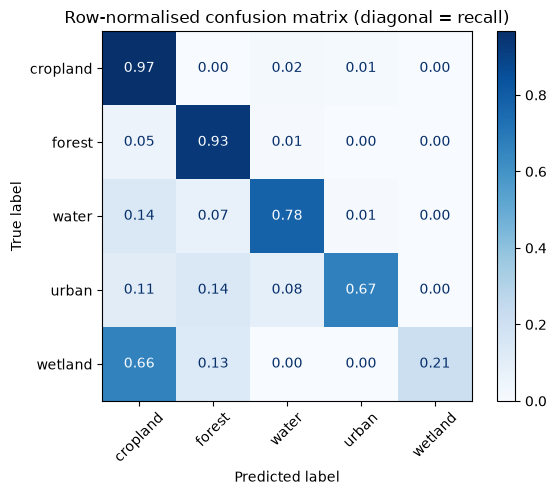

In [4]:
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
Xm, ym = make_classification(3000, 15, n_informative=8, n_classes=5, weights=[0.5, 0.25, 0.15, 0.07, 0.03],
                             n_clusters_per_class=1, class_sep=1.0, random_state=0)
names = ["cropland", "forest", "water", "urban", "wetland"]
Xa, Xb, ya, yb = train_test_split(Xm, ym, test_size=0.4, stratify=ym, random_state=0)
pm = RandomForestClassifier(300, random_state=0, n_jobs=-1).fit(Xa, ya).predict(Xb)
print(classification_report(yb, pm, target_names=names, digits=3))
cmm = confusion_matrix(yb, pm, normalize="true")
ConfusionMatrixDisplay(cmm, display_labels=names).plot(cmap="Blues", values_format=".2f", xticks_rotation=45)
plt.title("Row-normalised confusion matrix (diagonal = recall)"); plt.show()

## **4. ROC and Precision-Recall Curves**
Varying the threshold traces a curve:
- **ROC**: TPR vs FPR. AUC = probability that a random positive is scored higher than a random negative. Baseline 0.5.
- **PR**: precision vs recall. Average Precision (AP) baseline = positive rate. **Prefer PR for rare positives** (Day 21).

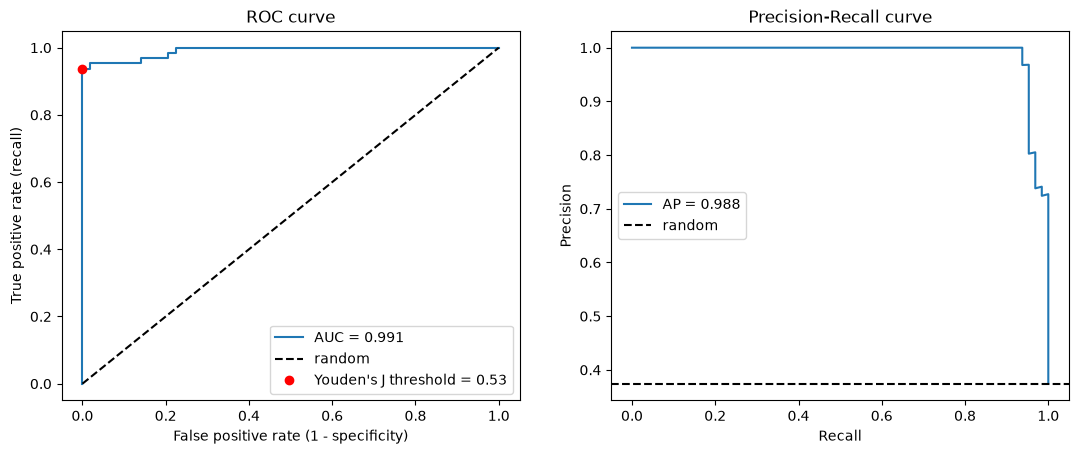

In [5]:
fpr, tpr, roc_thr = roc_curve(y_te, y_score)
prec, rec, pr_thr = precision_recall_curve(y_te, y_score)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_te, y_score):.3f}"); axes[0].plot([0, 1], [0, 1], "k--", label="random")
j = np.argmax(tpr - fpr)
axes[0].plot(fpr[j], tpr[j], "ro", label=f"Youden's J threshold = {roc_thr[j]:.2f}")
axes[0].set(xlabel="False positive rate (1 - specificity)", ylabel="True positive rate (recall)", title="ROC curve"); axes[0].legend()
axes[1].plot(rec, prec, label=f"AP = {average_precision_score(y_te, y_score):.3f}"); axes[1].axhline(y_te.mean(), c="k", ls="--", label="random")
axes[1].set(xlabel="Recall", ylabel="Precision", title="Precision-Recall curve"); axes[1].legend()
plt.show()

### AUC as a ranking probability (check)

In [6]:
pos, neg = y_score[y_te == 1], y_score[y_te == 0]
print("P(score_pos > score_neg) =", round(np.mean(pos[:, None] > neg[None, :]) + 0.5 * np.mean(pos[:, None] == neg[None, :]), 4),
      "| roc_auc_score =", round(roc_auc_score(y_te, y_score), 4))

P(score_pos > score_neg) = 0.9908 | roc_auc_score = 0.9908


## **5. Kappa, MCC and Balanced Accuracy**
**Cohen's Kappa** compares observed agreement with agreement expected by chance: $\kappa = \frac{p_o - p_e}{1-p_e}$. It was standard in remote sensing for decades, but Pontius & Millones (2011) and Foody (2020) showed it is **redundant with accuracy and misleading** (chance agreement is not a meaningful baseline for a map). Many journals now prefer reporting the full confusion matrix, overall accuracy, and user's/producer's accuracies with CIs. **MCC** is a robust single number for binary problems (Chicco & Jurman, 2020).

In [7]:
print(f"Accuracy {accuracy_score(yb, pm):.3f} | balanced acc {balanced_accuracy_score(yb, pm):.3f} | "
      f"Kappa {cohen_kappa_score(yb, pm):.3f} | MCC {matthews_corrcoef(yb, pm):.3f}")

Accuracy 0.885 | balanced acc 0.712 | Kappa 0.821 | MCC 0.823


## **6. Probability Quality: Log Loss and Brier Score**
Two models with the same accuracy can have very different probabilities. **Proper scoring rules** reward honest probabilities.
- **Log loss** = cross-entropy (Day 12). Harsh on confident mistakes.
- **Brier score** = mean $(p - y)^2$. Bounded, decomposes into calibration + refinement.

In [8]:
overconf = np.clip(np.where(y_score > 0.5, 0.999, 0.001), 0, 1)
print(f"Calibrated model : accuracy {accuracy_score(y_te, y_score > 0.5):.3f} | log loss {log_loss(y_te, y_score):.3f} | Brier {brier_score_loss(y_te, y_score):.4f}")
print(f"Overconfident    : accuracy {accuracy_score(y_te, overconf > 0.5):.3f} | log loss {log_loss(y_te, overconf):.3f} | Brier {brier_score_loss(y_te, overconf):.4f}")

Calibrated model : accuracy 0.971 | log loss 0.134 | Brier 0.0355
Overconfident    : accuracy 0.971 | log loss 0.203 | Brier 0.0292


Same accuracy, but the overconfident model's few mistakes are made with ~100% confidence. **Log loss** punishes this heavily. The **Brier score** is bounded (a confident mistake costs at most 1), so with 97% accuracy it actually prefers the overconfident model here. Two proper scoring rules can disagree. Report both, and inspect a reliability diagram (Day 29).

# **Part 2: Remote Sensing Accuracy Assessment Conventions**

Remote sensing papers present the confusion matrix with **reference (truth) in columns** and **map (predicted) in rows** (Congalton, 1991; Olofsson et al., 2014). Then:
- **User's accuracy** (UA) = correct / row total = **precision** of a map class. 1 - UA = **commission error**.
- **Producer's accuracy** (PA) = correct / column total = **recall**. 1 - PA = **omission error**.

The function below builds a publication-style table. Day 88 adds the area-weighted estimators and confidence intervals required for stratified samples.

In [9]:
def rs_accuracy_table(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred).T                         # rows = map, columns = reference
    t = pd.DataFrame(cm, index=[f"map: {l}" for l in labels], columns=[f"ref: {l}" for l in labels])
    t["Total"] = t.sum(1)
    ua = np.diag(cm) / cm.sum(1); pa = np.diag(cm) / cm.sum(0)
    t["UA (%)"] = (100 * ua).round(1)
    col_tot = list(cm.sum(0)) + [cm.sum(), np.nan]
    t.loc["Total"] = col_tot
    t.loc["PA (%)"] = list((100 * pa).round(1)) + [np.nan, np.nan]
    f1 = 2 * ua * pa / (ua + pa)
    summary = {"Overall accuracy (%)": 100 * np.trace(cm) / cm.sum(), "Kappa": cohen_kappa_score(y_true, y_pred), "Macro F1": f1.mean()}
    return t, summary

table, summary = rs_accuracy_table(yb, pm, names)
display(table)
print({k: round(float(v), 3) for k, v in summary.items()})

,ref: cropland,ref: forest,ref: water,ref: urban,ref: wetland,Total,UA (%)
map: cropland,576.0,16.0,25.0,9.0,25.0,651.0,88.5
map: forest,2.0,279.0,13.0,12.0,5.0,311.0,89.7
map: water,10.0,3.0,143.0,7.0,0.0,163.0,87.7
map: urban,8.0,1.0,2.0,56.0,0.0,67.0,83.6
map: wetland,0.0,0.0,0.0,0.0,8.0,8.0,100.0
Total,596.0,299.0,183.0,84.0,38.0,1200.0,NaN
PA (%),96.6,93.3,78.1,66.7,21.1,NaN,NaN


{'Overall accuracy (%)': 88.5, 'Kappa': 0.821, 'Macro F1': 0.751}


## **Practice Problems**
1. A test finds 90 of 100 diseased people and wrongly flags 50 of 900 healthy ones. Compute precision, recall, specificity, F1 and MCC by hand.
2. For the breast-cancer model, find the threshold that gives recall >= 0.98. What is the precision there?
3. Compute macro, weighted and micro F1 for the 5-class problem. Why is macro the lowest?
4. *(Advanced)* Show with a simulation that Kappa can **differ** for two maps with identical overall accuracy but different class proportions.

In [10]:
# Solution 1
TP, FN, FP, TN = 90, 10, 50, 850
P_, R_ = TP / (TP + FP), TP / (TP + FN)
print(f"precision {P_:.3f}, recall {R_:.3f}, specificity {TN / (TN + FP):.3f}, F1 {2 * P_ * R_ / (P_ + R_):.3f}, "
      f"MCC {(TP * TN - FP * FN) / np.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN)):.3f}")
# Solution 2
ok = rec[:-1] >= 0.98
print(f"threshold {pr_thr[ok].max():.3f}: recall {rec[:-1][ok][np.argmax(pr_thr[ok])]:.3f}, precision {prec[:-1][ok][np.argmax(pr_thr[ok])]:.3f}")
# Solution 3
print({a: round(f1_score(yb, pm, average=a), 3) for a in ["macro", "weighted", "micro"]}, "-> rare classes (wetland) have low F1 and count fully in macro")
# Solution 4
def make_map(props, acc, n=10000, seed=0):
    r = np.random.default_rng(seed); t = r.choice(len(props), n, p=props)
    wrong = r.random(n) > acc; p = t.copy(); p[wrong] = (t[wrong] + r.integers(1, len(props), wrong.sum())) % len(props)
    return t, p
for props in [[0.25, 0.25, 0.25, 0.25], [0.85, 0.05, 0.05, 0.05]]:
    t, p = make_map(props, 0.85)
    print(f"class proportions {props}: OA {accuracy_score(t, p):.3f}, Kappa {cohen_kappa_score(t, p):.3f}")

precision 0.643, recall 0.900, specificity 0.944, F1 0.750, MCC 0.730
threshold 0.152: recall 0.984, precision 0.741
{'macro': 0.751, 'weighted': 0.876, 'micro': 0.885} -> rare classes (wetland) have low F1 and count fully in macro
class proportions [0.25, 0.25, 0.25, 0.25]: OA 0.852, Kappa 0.803
class proportions [0.85, 0.05, 0.05, 0.05]: OA 0.852, Kappa 0.587


## **Key References**
- Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. *Information Processing & Management*, 45(4), 427-437.
- Fawcett, T. (2006). An introduction to ROC analysis. *Pattern Recognition Letters*, 27(8), 861-874.
- Chicco, D., & Jurman, G. (2020). The advantages of the Matthews correlation coefficient (MCC) over F1 score and accuracy in binary classification evaluation. *BMC Genomics*, 21, 6.
- Congalton, R. G. (1991). A review of assessing the accuracy of classifications of remotely sensed data. *Remote Sensing of Environment*, 37(1), 35-46.
- Pontius, R. G., & Millones, M. (2011). Death to Kappa: birth of quantity disagreement and allocation disagreement for accuracy assessment. *International Journal of Remote Sensing*, 32(15), 4407-4429.
- Foody, G. M. (2020). Explaining the unsuitability of the kappa coefficient in the assessment and comparison of the accuracy of thematic maps obtained by image classification. *Remote Sensing of Environment*, 239, 111630.